<a href="https://colab.research.google.com/github/vishwakarmaadesh-datascience/multi-disease-prediction-system-ensemble-learning/blob/main/multi_disease_prediction_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Data loading

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.base import clone # Import clone for creating fresh model instances
# =========================
# 1. Load Datasets
# =========================
diabetes = pd.read_csv('/content/diabetes.csv')
stroke = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')
heart = pd.read_csv('/content/heart.csv')
kidney = pd.read_csv('/content/kidney_disease.csv')
liver = pd.read_csv('/content/Liver_disease_data.csv')
print("Diabetes:", diabetes.columns.tolist())
print("Stroke:", stroke.columns.tolist())
print("Heart:", heart.columns.tolist())
print("Kidney:", kidney.columns.tolist())
print("Liver:", liver.columns.tolist())
# =========================
# Show HEAD and TAIL of Raw Datasets
# =========================
datasets = {
    "Diabetes": diabetes,
    "Stroke": stroke,
    "Heart": heart,
    "Kidney": kidney,
    "Liver": liver
}
for name, df in datasets.items():
    print(f"\n===== {name} DATASET =====")
    print("\n--- HEAD ---")
    display(df.head())
    print("\n--- TAIL ---")
    display(df.tail())

Diabetes: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Stroke: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
Heart: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Kidney: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']
Liver: ['Age', 'Gender', 'BMI', 'AlcoholConsumption', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'Diabetes', 'Hypertension', 'LiverFunctionTest', 'Diagnosis']

===== Diabetes DATASET =====

--- HEAD ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- TAIL ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0



===== Stroke DATASET =====

--- HEAD ---


...

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd
399,399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,53,6800,6.1,no,no,no,good,no,no,notckd



===== Liver DATASET =====

--- HEAD ---


,Age,Gender,BMI,AlcoholConsumption,Smoking,GeneticRisk,PhysicalActivity,Diabetes,Hypertension,LiverFunctionTest,Diagnosis
0,58,0,35.857584,17.272828,0,1,0.658940,0,0,42.734240,1
1,71,1,30.732470,2.201266,0,1,1.670557,1,0,67.309822,1
2,48,0,19.971407,18.500944,0,0,9.928308,0,0,63.738956,0
3,34,1,16.615417,12.632870,0,0,5.630129,0,0,64.555873,1
4,62,1,16.065830,1.087815,0,1,3.566218,1,0,77.868689,1



--- TAIL ---


,Age,Gender,BMI,AlcoholConsumption,Smoking,GeneticRisk,PhysicalActivity,Diabetes,Hypertension,LiverFunctionTest,Diagnosis
1695,42,0,38.498295,14.384688,0,1,0.992289,0,0,97.933961,1
1696,40,0,27.600094,5.431009,0,0,8.390492,0,0,70.260528,1
1697,38,0,38.730017,6.324302,1,2,9.314222,0,1,56.053370,1
1698,67,0,35.820798,16.899417,0,2,3.224453,0,0,26.300875,1
1699,80,0,24.060783,9.526447,0,0,9.261426,0,1,73.572893,1


2.Preprocessing

In [2]:
# 2. Preprocessing Functions
# ======================================================
def preprocess_diabetes(df):
    df = df.copy()
    # Replace 0 with NaN for specific columns and fill with median
    for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
        df[col] = df[col].replace(0, np.nan).fillna(df[col].median())
    # (Optional) Clip outliers to reduce noise
    for col in ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']:
        df[col] = df[col].clip(lower=df[col].quantile(0.01), upper=df[col].quantile(0.99))
    return df
def preprocess_stroke(df):
    df = df.copy()
    df = df.drop(columns=['id'], errors='ignore')
    df['bmi'] = df['bmi'].fillna(df['bmi'].median())
    # Remove this line or comment it out:
    # df['smoking_status'] = df['smoking_status'].replace('Unknown', df['smoking_status'].mode()[0])
    cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    return df
def preprocess_heart(df):
    df = df.copy()
    # Heart dataset is numeric in most versions; just clip extreme outliers a bit
    for col in df.columns:
        if col != 'target':
            df[col] = df[col].clip(lower=df[col].quantile(0.01),
                                   upper=df[col].quantile(0.99))
    return df
def preprocess_kidney(df):
    df = df.copy()
    # Drop 'id' column if it exists
    df = df.drop(columns=['id'], errors='ignore')
    # Map classification values ONLY IF 'classification' column exists
    if 'classification' in df.columns:
        df['classification'] = df['classification'].replace({'ckd': 1, 'notckd': 0, 'ckd\t': 1})
    # Process columns
    for col in df.columns:
        # Skip 'classification' column if it's the target
        if col == 'classification':
            continue
        if df[col].dtype == 'object':
            # Fill missing values with mode and apply LabelEncoder
            df[col] = df[col].fillna(df[col].mode()[0])
            df[col] = LabelEncoder().fit_transform(df[col])
        else:
            # Convert to numeric and fill missing with median
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median())
    return df
def preprocess_liver(df):
    df = df.copy()
    # Encode Gender column
    df['Gender'] = LabelEncoder().fit_transform(df['Gender'])
    return df

3.Cleaning Data

In [10]:
# 3. Apply Cleaning
# =========================
diabetes_cleaned = preprocess_diabetes(diabetes)
stroke_cleaned = preprocess_stroke(stroke)
heart_cleaned = preprocess_heart(heart)
kidney_cleaned = preprocess_kidney(kidney)
liver_cleaned = preprocess_liver(liver)
# =========================
# 4. Show Cleaned Data
# =========================
def display_cleaned_data(name, df):
    print(f"\n=== Cleaned {name.capitalize()} ===")
    display(df.head())
    print(df.info())
display_cleaned_data('Diabetes', diabetes_cleaned)
display_cleaned_data('Stroke', stroke_cleaned)
display_cleaned_data('Heart', heart_cleaned)
display_cleaned_data('Kidney', kidney_cleaned)
display_cleaned_data('Liver', liver_cleaned)
# =========================


=== Cleaned Diabetes ===


/tmp/ipykernel_3526/2628274101.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['classification'] = df['classification'].replace({'ckd': 1, 'notckd': 0, 'ckd\t': 1})


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,30.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,30.5,26.6,0.351,31,0
2,8,183.0,64.0,23.0,30.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,44.0,35.0,168.0,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB
None

=== Cleaned Stroke ===


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,False,True,False,False,True,False,False,False,True,False


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

=== Cleaned Kidney ===


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,32,72,34,1,4,1,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,26,56,34,0,3,1,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,19,70,34,0,4,1,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,20,62,19,1,3,1,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,23,68,27,0,3,1,0,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    int64  
 6   pc              400 non-null    int64  
 7   pcc             400 non-null    int64  
 8   ba              400 non-null    int64  
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    int64  
 16  wc              400 non-null    int64  
 17  rc              400 non-null    int

,Age,Gender,BMI,AlcoholConsumption,Smoking,GeneticRisk,PhysicalActivity,Diabetes,Hypertension,LiverFunctionTest,Diagnosis
0,58,0,35.857584,17.272828,0,1,0.658940,0,0,42.734240,1
1,71,1,30.732470,2.201266,0,1,1.670557,1,0,67.309822,1
2,48,0,19.971407,18.500944,0,0,9.928308,0,0,63.738956,0
3,34,1,16.615417,12.632870,0,0,5.630129,0,0,64.555873,1
4,62,1,16.065830,1.087815,0,1,3.566218,1,0,77.868689,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1700 non-null   int64  
 1   Gender              1700 non-null   int64  
 2   BMI                 1700 non-null   float64
 3   AlcoholConsumption  1700 non-null   float64
 4   Smoking             1700 non-null   int64  
 5   GeneticRisk         1700 non-null   int64  
 6   PhysicalActivity    1700 non-null   float64
 7   Diabetes            1700 non-null   int64  
 8   Hypertension        1700 non-null   int64  
 9   LiverFunctionTest   1700 non-null   float64
 10  Diagnosis           1700 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 146.2 KB
None


5.Feature and Target

In [11]:
# 5. Define Features (X) and Targets (y) for each dataset
# =========================
# Diabetes dataset
X_diabetes = diabetes_cleaned.drop('Outcome', axis=1)
y_diabetes = diabetes_cleaned['Outcome']
# Stroke dataset
X_stroke = stroke_cleaned.drop('stroke', axis=1)
y_stroke = stroke_cleaned['stroke']
# Heart dataset
X_heart = heart_cleaned.drop('target', axis=1)
y_heart = heart_cleaned['target']
# Kidney dataset
X_kidney = kidney_cleaned.drop('classification', axis=1)
y_kidney = kidney_cleaned['classification']
# Liver dataset
X_liver = liver_cleaned.drop('Diagnosis', axis=1)
y_liver = liver_cleaned['Diagnosis']
# Helper to apply categorical encoding consistently
def _apply_categorical_encoding_consistent(df, reference_columns):
    df_processed = df.copy()

    # Handle label encoding for binary-like columns (if any still exist)
    for col in df_processed.select_dtypes(include=['object', 'category']).columns:
        if df_processed[col].nunique() == 2:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col])

    # One-hot encode
    # We do this by reindexing AFTER get_dummies
    df_processed = pd.get_dummies(df_processed, drop_first=True)

    # Force exactly the same columns as during training
    # Missing columns → fill with 0
    # Extra columns → dropped
    df_processed = df_processed.reindex(columns=reference_columns, fill_value=0)

    return df_processed

6.Split Data into training and testing

In [14]:
# 6. Generic Preprocess + Split Function
# ======================================================
def preprocess_and_split(X, y):
    X_copy = X.copy()
    # 1. Encode categorical columns (store these column names for later use)
    # This part should be consistent with _apply_categorical_encoding_consistent
    for col in X_copy.select_dtypes(include=['object', 'category']).columns:
        unique_vals = X_copy[col].nunique()
        if unique_vals == 2:
            le = LabelEncoder()
            X_copy[col] = le.fit_transform(X_copy[col])
    X_encoded = pd.get_dummies(X_copy, drop_first=True)
    # 2. Train-test split
    X_train_encoded, X_test_encoded, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42, stratify=y
    )
    # 3. Scale numeric features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_encoded)
    X_test = scaler.transform(X_test_encoded)
    return X_train, X_test, y_train, y_test, X_encoded.columns.tolist(), scaler # Return actual column names

# Apply to all datasets
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes, diabetes_final_features, diabetes_scaler = preprocess_and_split(X_diabetes, y_diabetes)
X_train_stroke, X_test_stroke, y_train_stroke, y_test_stroke, stroke_final_features, stroke_scaler = preprocess_and_split(X_stroke, y_stroke)
X_train_heart, X_test_heart, y_train_heart, y_test_heart, heart_final_features, heart_scaler = preprocess_and_split(X_heart, y_heart)
X_train_kidney, X_test_kidney, y_train_kidney, y_test_kidney, kidney_final_features, kidney_scaler = preprocess_and_split(X_kidney, y_kidney)
X_train_liver, X_test_liver, y_train_liver, y_test_liver, liver_final_features, liver_scaler = preprocess_and_split(X_liver, y_liver)

# Create the final_features dictionary using the real encoded column names from training
final_features = {
    "Diabetes": diabetes_final_features,
    "Stroke": stroke_final_features,
    "Heart": heart_final_features,
    "Kidney": kidney_final_features,
    "Liver": liver_final_features
}

# Save it to a file
import joblib
joblib.dump(final_features, "/content/final_features.pkl")
print("final_features saved successfully to /content/final_features.pkl")
# ======================================================

final_features saved successfully to /content/final_features.pkl


7. Define Algorithms

In [15]:
# 7. Define Ensembles (generic, diabetes-tuned, heart-regularized)
# ======================================================
# Generic ensemble for Stroke, Kidney, Liver (original style)
ensemble_generic = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=500)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
        ('svm', SVC(probability=True, random_state=42))
    ],
    voting='soft'
)
# Diabetes-specific ensemble (aimed at higher accuracy, class imbalance aware)
ensemble_diabetes = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(
            max_iter=1000, C=0.5, solver='liblinear', class_weight='balanced'
        )),
        ('rf', RandomForestClassifier(
            n_estimators=300, max_depth=6,
            min_samples_split=10, min_samples_leaf=4,
            random_state=42, class_weight='balanced'
        )),
        ('gb', GradientBoostingClassifier(
            random_state=42, n_estimators=200,
            learning_rate=0.05, max_depth=3
        )),
        ('xgb', XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            random_state=42,
            n_estimators=300, learning_rate=0.05,
            max_depth=3, subsample=0.8, colsample_bytree=0.8
        )),
        ('svm', SVC(
            probability=True, random_state=42,
            C=1.0, kernel='rbf', class_weight='balanced'
        ))
    ],
    voting='soft'
)
# Heart-specific ensemble (more regularized to reduce overfitting)
ensemble_heart = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(
            max_iter=1000, C=0.3, solver='liblinear'
        )),
        ('rf', RandomForestClassifier(
            n_estimators=150, max_depth=4,
            min_samples_leaf=5, random_state=42
        )),
        ('gb', GradientBoostingClassifier(
            random_state=42, n_estimators=100,
            learning_rate=0.05, max_depth=2
        )),
        ('xgb', XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            random_state=42,
            n_estimators=150, learning_rate=0.05,
            max_depth=2, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0
        )),
        ('svm', SVC(
            probability=True, random_state=42,
            C=0.5, kernel='rbf'
        ))
    ],
    voting='soft'
)

8. Train & Evaluate


===== DIABETES =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:44:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7468
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80       100
           1       0.64      0.65      0.64        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


===== STROKE =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:44:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9511
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022


===== HEART =====


...

Accuracy: 0.8976
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.87      0.89       100
           1       0.88      0.92      0.90       105

    accuracy                           0.90       205
   macro avg       0.90      0.90      0.90       205
weighted avg       0.90      0.90      0.90       205


===== KIDNEY =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:44:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


===== LIVER =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:44:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9000
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.89       153
           1       0.93      0.88      0.91       187

    accuracy                           0.90       340
   macro avg       0.90      0.90      0.90       340
weighted avg       0.90      0.90      0.90       340


=== Ensemble Model Results Across Datasets ===
    Dataset  Accuracy
0  Diabetes  0.746753
1    Stroke  0.951076
2     Heart  0.897561
3    Kidney  1.000000
4     Liver  0.900000


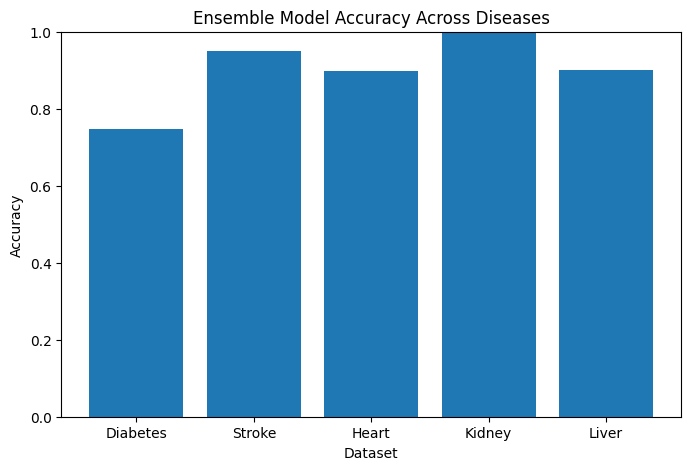

In [16]:
# 8. Train & Evaluate on Each Dataset
# =========================
def train_and_evaluate(name, X_train, X_test, y_train, y_test):
    print(f"\n===== {name.upper()} =====")
    # Choose appropriate ensemble definition and create a fresh clone
    if name.lower() == "diabetes":
        model_definition = ensemble_diabetes
    elif name.lower() == "heart":
        model_definition = ensemble_heart
    else:
        model_definition = ensemble_generic
    model = clone(model_definition)
    # Fit model
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    return acc, model # Return the fitted model instance
# Run for all datasets and capture fitted models
acc_diabetes, fitted_ensemble_diabetes = train_and_evaluate("Diabetes", X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes)
acc_stroke, fitted_ensemble_stroke = train_and_evaluate("Stroke", X_train_stroke, X_test_stroke, y_train_stroke, y_test_stroke)
acc_heart, fitted_ensemble_heart = train_and_evaluate("Heart", X_train_heart, X_test_heart, y_train_heart, y_test_heart)
acc_kidney, fitted_ensemble_kidney = train_and_evaluate("Kidney", X_train_kidney, X_test_kidney, y_train_kidney, y_test_kidney)
acc_liver, fitted_ensemble_liver = train_and_evaluate("Liver", X_train_liver, X_test_liver, y_train_liver, y_test_liver)
#Summarize Results
# =========================
results = pd.DataFrame({
    "Dataset": ["Diabetes", "Stroke", "Heart", "Kidney", "Liver"],
    "Accuracy": [acc_diabetes, acc_stroke, acc_heart, acc_kidney, acc_liver]
})
print("\n=== Ensemble Model Results Across Datasets ===")
print(results)
# Visualization
plt.figure(figsize=(8, 5))
plt.bar(results["Dataset"], results["Accuracy"])
plt.ylim(0, 1)
plt.title("Ensemble Model Accuracy Across Diseases")
plt.ylabel("Accuracy")
plt.xlabel("Dataset")
plt.show()

10.Comapring model performance


===== DIABETES =====
Logistic Regression: 0.7143
Random Forest: 0.7468
Gradient Boosting: 0.7468
XGBoost: 0.7403
SVM: 0.7532


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:45:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:45:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Ensemble: 0.7468

===== STROKE =====
Logistic Regression: 0.9521
Random Forest: 0.9481
Gradient Boosting: 0.9481
XGBoost: 0.9423


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:45:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM: 0.9511


...

Ensemble: 1.0000

===== LIVER =====
Logistic Regression: 0.8265
Random Forest: 0.8941
Gradient Boosting: 0.9029
XGBoost: 0.8882


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:45:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM: 0.8471


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:45:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Ensemble: 0.9000

=== Model Comparison Table ===
                     Diabetes    Stroke     Heart  Kidney     Liver
Logistic Regression  0.714286  0.952055  0.814634  0.9875  0.826471
Random Forest        0.746753  0.948141  0.892683  1.0000  0.894118
Gradient Boosting    0.746753  0.948141  0.882927  0.9875  0.902941
XGBoost              0.740260  0.942270  0.887805  0.9875  0.888235
SVM                  0.753247  0.951076  0.902439  0.9750  0.847059
Ensemble             0.746753  0.951076  0.897561  1.0000  0.900000


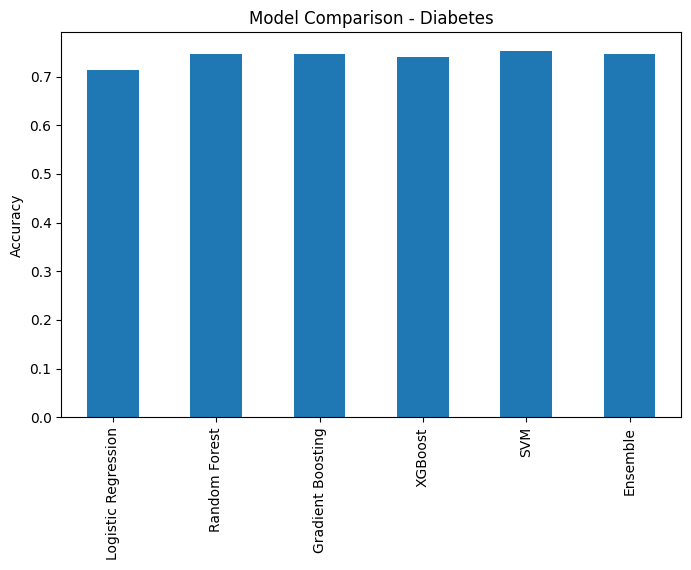

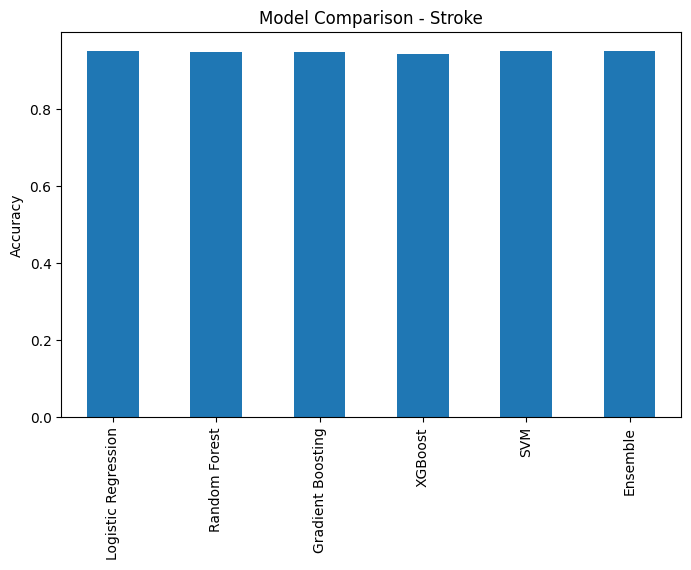

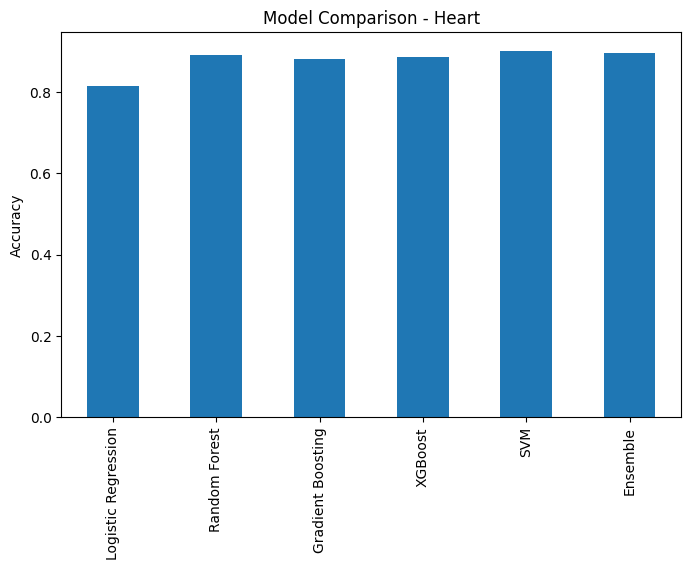

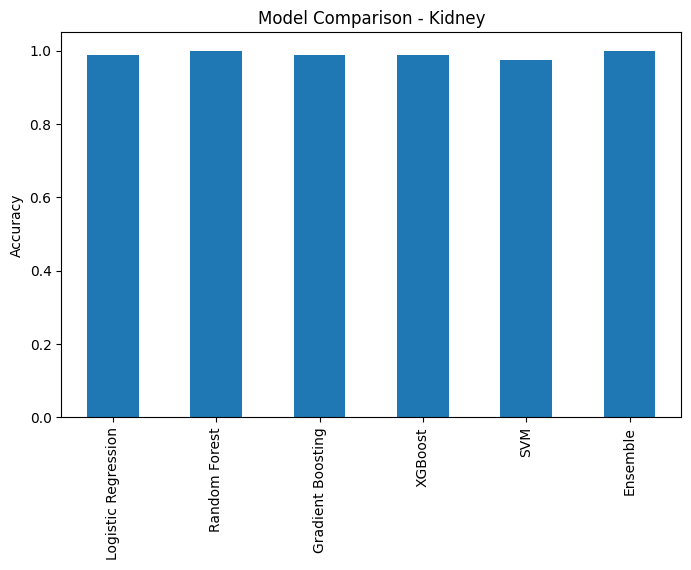

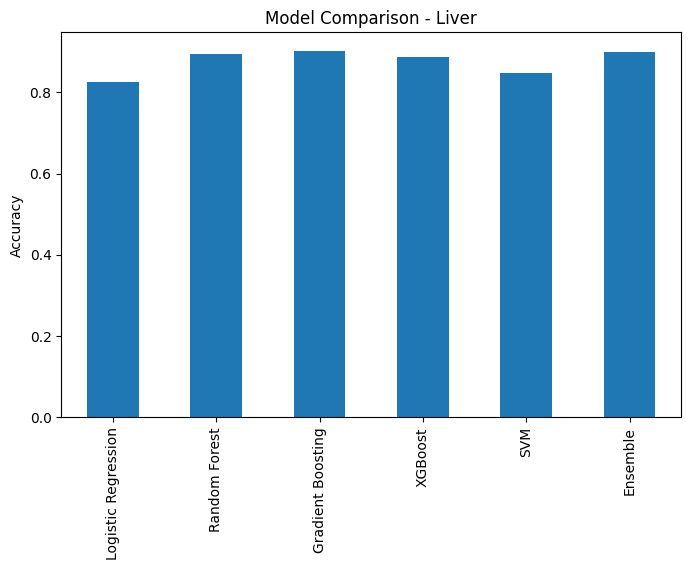

In [17]:
# 10. Compare Individual Models vs Ensemble
# ======================================================
# Generic models (definitions)
models_generic = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Ensemble": ensemble_generic # Reference to the global definition
}
# Diabetes-tuned models (definitions)
models_diabetes = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=0.5, solver='liblinear', class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=6,
        min_samples_split=10, min_samples_leaf=4,
        random_state=42, class_weight='balanced'
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42, n_estimators=200,
        learning_rate=0.05, max_depth=3
    ),
    "XGBoost": XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        random_state=42,
        n_estimators=300, learning_rate=0.05,
        max_depth=3, subsample=0.8, colsample_bytree=0.8
    ),
    "SVM": SVC(
        probability=True, random_state=42,
        C=1.0, kernel='rbf', class_weight='balanced'
    ),
    "Ensemble": ensemble_diabetes # Reference to the global definition
}
# Heart-regularized models (definitions)
models_heart = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=0.3, solver='liblinear'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=4,
        min_samples_leaf=5, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42, n_estimators=100,
        learning_rate=0.05, max_depth=2
    ),
    "XGBoost": XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        random_state=42,
        n_estimators=150, learning_rate=0.05,
        max_depth=2, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0
    ),
    "SVM": SVC(
        probability=True, random_state=42,
        C=0.5, kernel='rbf'
        ),
    "Ensemble": ensemble_heart # Reference to the global definition
}
def evaluate_models(name, X_train, X_test, y_train, y_test):
    print(f"\n===== {name.upper()} =====")
    if name.lower() == "diabetes":
        # Create fresh clones of all models in the dictionary
        local_models = {k: clone(v) for k, v in models_diabetes.items()}
    elif name.lower() == "heart":
        local_models = {k: clone(v) for k, v in models_heart.items()}
    else:
        local_models = {k: clone(v) for k, v in models_generic.items()}
    scores = {}
    for model_name, model in local_models.items():
        # 'model' here is a fresh clone, safe to fit without modifying global definitions
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)
        scores[model_name] = acc
        print(f"{model_name}: {acc:.4f}")
    return scores
# Run comparisons for each dataset
results_comparison = {
    "Diabetes": evaluate_models("Diabetes", X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes),
    "Stroke": evaluate_models("Stroke", X_train_stroke, X_test_stroke, y_train_stroke, y_test_stroke),
    "Heart": evaluate_models("Heart", X_train_heart, X_test_heart, y_train_heart, y_test_heart),
    "Kidney": evaluate_models("Kidney", X_train_kidney, X_test_kidney, y_train_kidney, y_test_kidney),
    "Liver": evaluate_models("Liver", X_train_liver, X_test_liver, y_train_liver, y_test_liver),
}
# Convert results into DataFrame
df_comparison = pd.DataFrame(results_comparison)
print("\n=== Model Comparison Table ===")
print(df_comparison)
# Plot comparison for each dataset
df_comparison["Diabetes"].plot(kind="bar", figsize=(8, 5), title="Model Comparison - Diabetes")
plt.ylabel("Accuracy")
plt.show()
df_comparison["Stroke"].plot(kind="bar", figsize=(8, 5), title="Model Comparison - Stroke")
plt.ylabel("Accuracy")
plt.show()
df_comparison["Heart"].plot(kind="bar", figsize=(8, 5), title="Model Comparison - Heart")
plt.ylabel("Accuracy")
plt.show()
df_comparison["Kidney"].plot(kind="bar", figsize=(8, 5), title="Model Comparison - Kidney")
plt.ylabel("Accuracy")
plt.show()
df_comparison["Liver"].plot(kind="bar", figsize=(8, 5), title="Model Comparison - Liver")
plt.ylabel("Accuracy")
plt.show()

11. Feature Importance


=== Top Features for Diabetes ===
                    Feature  Importance
1                   Glucose    0.276364
5                       BMI    0.163589
6  DiabetesPedigreeFunction    0.124197
7                       Age    0.119121
2             BloodPressure    0.088641
0               Pregnancies    0.082827
4                   Insulin    0.073529
3             SkinThickness    0.071732


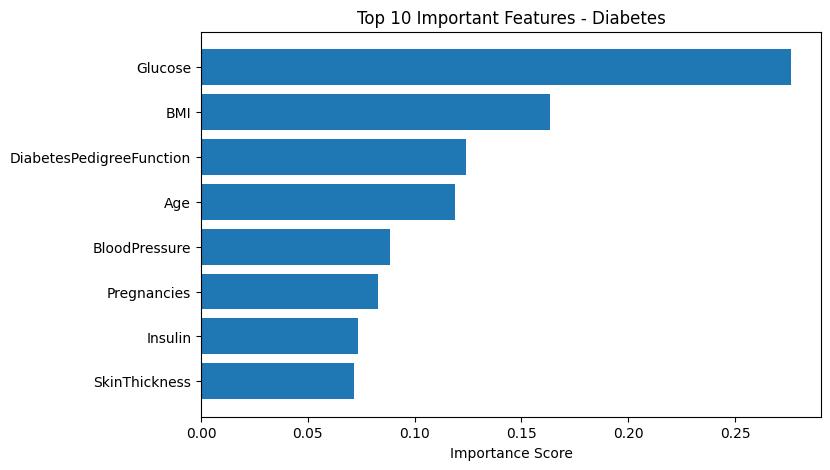


=== Top Features for Stroke ===
                        Feature  Importance
3             avg_glucose_level    0.280785
0                           age    0.235369
4                           bmi    0.232429
12         Residence_type_Urban    0.032823
5                   gender_Male    0.032118
9             work_type_Private    0.026891
1                  hypertension    0.026511
14  smoking_status_never smoked    0.026078
2                 heart_disease    0.022698
7              ever_married_Yes    0.021102


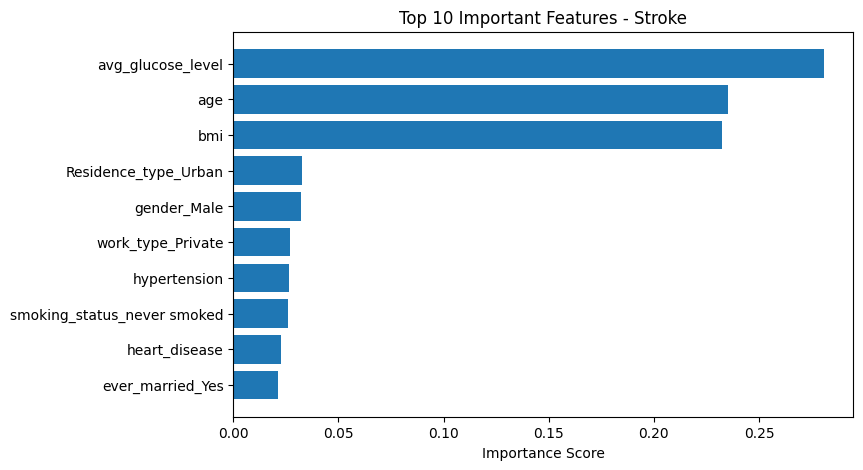


=== Top Features for Heart ===
     Feature  Importance
2         cp    0.144350
7    thalach    0.117157
11        ca    0.115804
9    oldpeak    0.112658
12      thal    0.094352
0        age    0.093970
4       chol    0.077375
8      exang    0.071534
3   trestbps    0.065009
10     slope    0.048141


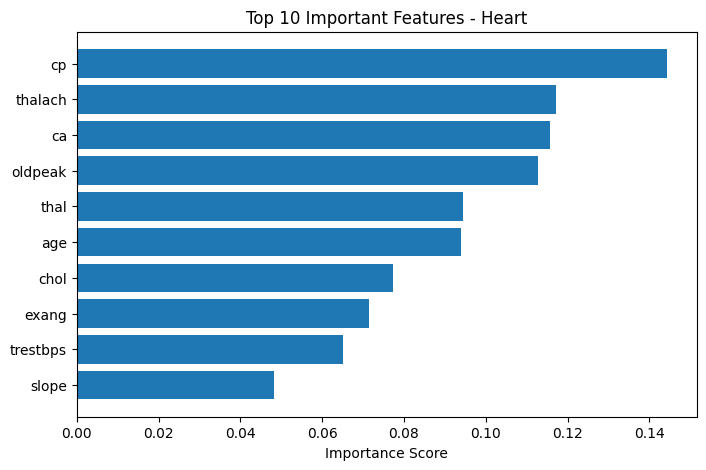


=== Top Features for Kidney ===
   Feature  Importance
14    hemo    0.180319
11      sc    0.161201
15     pcv    0.148742
2       sg    0.122619
17      rc    0.070025
3       al    0.068364
18     htn    0.054119
19      dm    0.043817
10      bu    0.034624
12     sod    0.021610


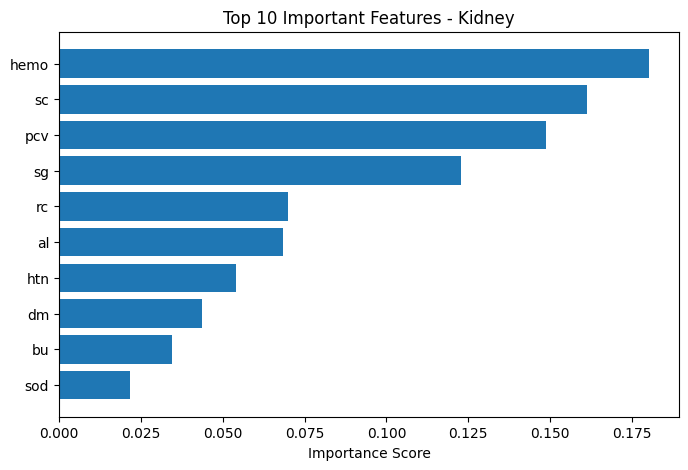


=== Top Features for Liver ===
              Feature  Importance
3  AlcoholConsumption    0.242057
9   LiverFunctionTest    0.241359
2                 BMI    0.118948
0                 Age    0.108291
6    PhysicalActivity    0.106064
5         GeneticRisk    0.049373
1              Gender    0.043913
4             Smoking    0.042684
8        Hypertension    0.028982
7            Diabetes    0.018330


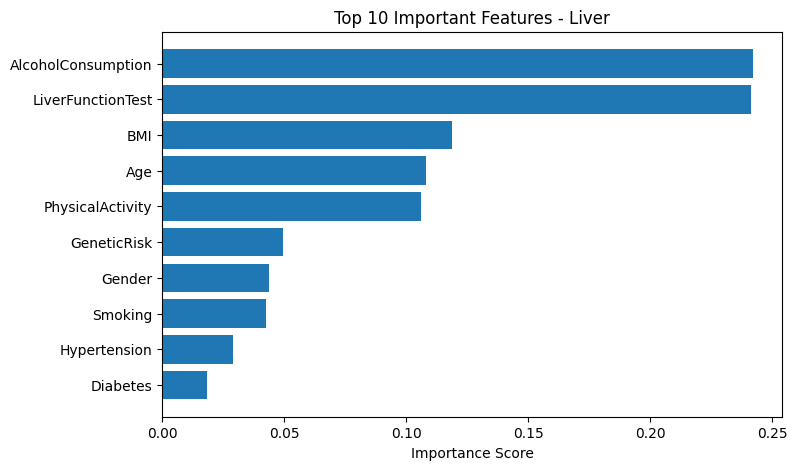

In [18]:
# ======================================================
# 11. Feature Importance Analysis (Random Forest)
# ======================================================
def feature_importance(model, X_original_df, dataset_name):
    # Re-apply categorical encoding to X_original_df to match feature names
    # used during training before passing to feature importance if X_original_df
    # doesn't already have one-hot encoded columns.
    if dataset_name.lower() == "diabetes":
        ref_cols = diabetes_final_features
    elif dataset_name.lower() == "stroke":
        ref_cols = stroke_final_features
    elif dataset_name.lower() == "heart":
        ref_cols = heart_final_features
    elif dataset_name.lower() == "kidney":
        ref_cols = kidney_final_features
    elif dataset_name.lower() == "liver":
        ref_cols = liver_final_features
    else:
        ref_cols = X_original_df.columns.tolist() # Fallback
    # Need to create a dummy X to get feature names after one-hot encoding if X_original_df
    # was not already one-hot encoded by preprocess_xxx functions.
    X_temp_encoded = _apply_categorical_encoding_consistent(X_original_df, ref_cols)
    features = X_temp_encoded.columns
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        importance_df = pd.DataFrame({
            "Feature": features,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)
        print(f"\n=== Top Features for {dataset_name} ===")
        print(importance_df.head(10)) # show top 10 features
        # Plot
        plt.figure(figsize=(8, 5))
        plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
        plt.gca().invert_yaxis()
        plt.title(f"Top 10 Important Features - {dataset_name}")
        plt.xlabel("Importance Score")
        plt.show()
    else:
        print(f"{dataset_name} model does not support feature importance.")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
# Diabetes
rf.fit(X_train_diabetes, y_train_diabetes)
feature_importance(rf, X_diabetes, "Diabetes")
# Stroke
rf.fit(X_train_stroke, y_train_stroke)
feature_importance(rf, X_stroke, "Stroke")
# Heart
rf.fit(X_train_heart, y_train_heart)
feature_importance(rf, X_heart, "Heart")
# Kidney
rf.fit(X_train_kidney, y_train_kidney)
feature_importance(rf, X_kidney, "Kidney")
# Liver
rf.fit(X_train_liver, y_train_liver)
feature_importance(rf, X_liver, "Liver")

12. Interactive Prediction for New Patient

In [19]:
# 12. Interactive Prediction for New Patient
# ======================================================
# Store final feature names after preprocessing_and_split's encoding
final_features = {
    "Diabetes": diabetes_final_features,
    "Stroke": stroke_final_features,
    "Heart": heart_final_features,
    "Kidney": kidney_final_features,
    "Liver": liver_final_features
}
# Define ranges for each dataset (based on dataset statistics and typical values)
ranges = {
    "Diabetes": {
        'Pregnancies': (0, 17),
        'Glucose': (44, 199),
        'BloodPressure': (0, 122),
        'SkinThickness': (7, 99),
        'Insulin': (16, 846),
        'BMI': (18.2, 67.1),
        'DiabetesPedigreeFunction': (0.078, 2.42),
        'Age': (21, 81)
    },
    "Stroke": {
        'age': (0.08, 79),
        'hypertension': (0, 1),
        'heart_disease': (0, 1),
        'avg_glucose_level': (55.1, 271.7),
        'bmi': (10.3, 97.6),
        'gender': ['Female', 'Male', 'Other'], # Explicitly list categories for user guidance
        'ever_married': ['Yes', 'No'],
        'work_type': ['children', 'Govt_job', 'Never_worked', 'Private', 'Self-employed'],
        'Residence_type': ['Urban', 'Rural'],
        'smoking_status': ['formerly smoked', 'never smoked', 'smokes'] # 'Unknown' is handled in preprocess_stroke
    },
    "Heart": {
        'age': (29, 77),
        'sex': (0, 1), # Female:0, Male:1
        'cp': (0, 3), # chest pain type
        'trestbps': (94, 200),
        'chol': (126, 564),
        'fbs': (0, 1), # fasting blood sugar > 120 mg/dl
        'restecg': (0, 2), # resting electrocardiographic results
        'thalach': (71, 202),
        'exang': (0, 1), # exercise induced angina
        'oldpeak': (0, 6.2),
        'slope': (0, 2),
        'ca': (0, 4), # number of major vessels (0-4) colored by flourosopy
        'thal': (0, 3) # Thalassemia (0=normal; 1=fixed defect; 2=reversible defect) -> some sources say 3 is also possible
    },
    "Kidney": { # Label encoded, ranges approximate 0 to n_classes-1 for cats, numeric min-max
        'age': (2, 90),
        'bp': (50, 180),
        'sg': (1.005, 1.025),
        'al': (0, 5),
        'su': (0, 5),
        'rbc': (0, 1), # normal:1, abnormal:0
        'pc': (0, 1), # normal:1, abnormal:0
        'pcc': (0, 1), # present:1, notpresent:0
        'ba': (0, 1), # present:1, notpresent:0
        'bgr': (22, 490),
        'bu': (1.5, 391),
        'sc': (0.4, 76),
        'sod': (111, 150),
        'pot': (2.5, 47),
        'hemo': (3.1, 17.8),
        'pcv': (9, 54),
        'wc': (2200, 26400),
        'rc': (2.1, 8.0),
        'htn': (0, 1), # yes:1, no:0
        'dm': (0, 1), # yes:1, no:0 -> originally 0-4 for one-hot like encoding, simplify for input
        'cad': (0, 1), # yes:1, no:0
        'appet': (0, 1), # good:0, poor:1
        'pe': (0, 1), # yes:1, no:0
        'ane': (0, 1) # yes:1, no:0
    },
    "Liver": {
        'Age': (1, 90),
        'Gender': ['Male', 'Female'], # Use string categories for input
        'BMI': (12.4, 47.9),
        'AlcoholConsumption': (0, 71),
        'Smoking': (0, 1),
        'GeneticRisk': (0, 1),
        'PhysicalActivity': (0, 10),
        'Diabetes': (0, 1),
        'Hypertension': (0, 1),
        'LiverFunctionTest': (0, 100)
    }
}
# Get original feature lists for user input (before one-hot encoding for categorical)
original_features_for_input = {
    "Diabetes": X_diabetes.columns.tolist(),
    "Stroke": ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status'],
    "Heart": X_heart.columns.tolist(),
    "Kidney": X_kidney.columns.tolist(),
    "Liver": ['Age', 'Gender', 'BMI', 'AlcoholConsumption', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'Diabetes', 'Hypertension', 'LiverFunctionTest']
}
# Get scalers (from preprocess_and_split function call)
scalers = {
    "Diabetes": diabetes_scaler,
    "Stroke": stroke_scaler,
    "Heart": heart_scaler,
    "Kidney": kidney_scaler,
    "Liver": liver_scaler
}
# Get models (now using the fitted instances from train_and_evaluate)
models_for_prediction = {
    "Diabetes": fitted_ensemble_diabetes,
    "Stroke": fitted_ensemble_stroke,
    "Heart": fitted_ensemble_heart,
    "Kidney": fitted_ensemble_kidney,
    "Liver": fitted_ensemble_liver
}
def _apply_disease_specific_preprocessing(df_raw, selected_disease):
    df_copy = df_raw.copy()
    if selected_disease == "Diabetes":
        # No additional feature engineering needed here for the raw input, as it will be scaled/encoded later.
        pass
    elif selected_disease == "Stroke":
        # Original preprocess_stroke handles ID, BMI fill, smoking_status 'Unknown', and one-hot encoding
        # For input, we just need to ensure categorical columns are handled correctly before one-hot
        pass
    elif selected_disease == "Heart":
        # Original preprocess_heart handles clipping and one-hot encoding for categoricals
        pass
    elif selected_disease == "Kidney":
        # Original preprocess_kidney handles ID, mapping classification, and label encoding
        pass
    elif selected_disease == "Liver":
        # Original preprocess_liver handles Gender encoding
        pass
    return df_copy
def prepare_new_data_for_prediction(new_data_dict, selected_disease, final_feature_columns):
    df_raw_input = pd.DataFrame([new_data_dict])
    # 1. Apply disease-specific feature engineering (if any was done on raw columns before one-hot)
    # For this current notebook structure, it's more direct to apply the original preprocessing
    # function to the raw input, and then rely on _apply_categorical_encoding_consistent
    # and reindexing to align columns.
    if selected_disease == "Diabetes":
        df_processed_temp = preprocess_diabetes(df_raw_input)
    elif selected_disease == "Stroke":
        df_processed_temp = preprocess_stroke(df_raw_input)
    elif selected_disease == "Heart":
        df_processed_temp = preprocess_heart(df_raw_input)
    elif selected_disease == "Kidney":
        df_processed_temp = preprocess_kidney(df_raw_input)
    elif selected_disease == "Liver":
        df_processed_temp = preprocess_liver(df_raw_input)
    else:
        df_processed_temp = df_raw_input
    # Ensure Gender in Liver is handled as an object for LabelEncoder inside _apply_categorical_encoding_consistent
    # REMOVED: This line was incorrectly converting Gender back to object after it was already integer-encoded.
    # if selected_disease == "Liver" and 'Gender' in df_processed_temp.columns:
    # df_processed_temp['Gender'] = df_processed_temp['Gender'].astype('object')
    df_processed = _apply_categorical_encoding_consistent(df_processed_temp, final_feature_columns)
    return df_processed

13. Final Prediction

In [20]:
print("\n=== Disease Prediction for New Patient ===")
while True:
    print("\nChoose a disease for prediction (or type 'quit' to exit):")
    for i, disease in enumerate(models_for_prediction.keys(), 1):
        print(f"{i}. {disease}")
    user_choice = input("Enter choice (1-5) or 'quit': ")
    if user_choice.lower() == 'quit':
        print("Exiting prediction system.")
        break
    try:
        choice = int(user_choice) - 1
        diseases = list(models_for_prediction.keys())
        selected_disease = diseases[choice]
    except (ValueError, IndexError):
        print("Invalid choice. Please enter a number between 1 and 5, or 'quit'.")
        continue
    print(f"\nSelected Disease: {selected_disease}")
    print("Please enter the following patient details (numeric values only where applicable).")
    print("--- Feature Ranges for Accurate Predictions ---\n")
    new_data = {}
    for feature in original_features_for_input[selected_disease]:
        if feature in ranges[selected_disease]:
            # For ranges that are lists of strings (categorical values)
            if isinstance(ranges[selected_disease][feature], list):
                possible_values = ", ".join(ranges[selected_disease][feature])
                print(f" {feature}: ({possible_values})")
            else: # Numeric range
                min_val, max_val = ranges[selected_disease][feature]
                print(f" {feature}: [{min_val:.2f} - {max_val:.2f}]")
        else:
            print(f" {feature}: (categorical - specific values needed)") # Fallback for other categoricals
        while True:
            val_input = input(f"Enter value for {feature}: ")
            is_string_categorical = False
            if selected_disease == "Stroke" and feature in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
                is_string_categorical = True
                valid_input = True
                if feature == 'ever_married':
                    if val_input.lower() in ['yes', 'no']:
                        new_data[feature] = val_input.capitalize()
                    else:
                        print(f" Invalid {feature}. Please choose from: Yes, No.")
                        valid_input = False
                elif feature == 'gender':
                    if val_input.lower() in [s.lower() for s in ranges[selected_disease][feature]]: # Check against defined categories
                        new_data[feature] = val_input.capitalize()
                    else:
                        print(f" Invalid {feature}. Please choose from: {', '.join(ranges[selected_disease][feature])}.")
                        valid_input = False
                elif feature == 'Residence_type':
                    if val_input.lower() in [s.lower() for s in ranges[selected_disease][feature]]:
                        new_data[feature] = val_input.capitalize()
                    else:
                        print(f" Invalid {feature}. Please choose from: {', '.join(ranges[selected_disease][feature])}.")
                        valid_input = False
                elif feature == 'smoking_status':
                    if val_input.lower() in [s.lower() for s in ranges[selected_disease][feature]]:
                        new_data[feature] = val_input.lower()
                    else:
                        print(f" Invalid {feature}. Please choose from: {', '.join(ranges[selected_disease][feature])}.")
                        valid_input = False
                elif feature == 'work_type':
                    # Normalize for consistency with preprocess_stroke and check validity
                    expected_work_types = [s.replace('_', ' ').lower() for s in ranges[selected_disease][feature]]
                    if val_input.lower() in expected_work_types:
                        new_data[feature] = val_input.replace(" ", "_").capitalize()
                    else:
                        print(f" Invalid {feature}. Please choose from: {', '.join(ranges[selected_disease][feature])}.")
                        valid_input = False
                if valid_input:
                    break # Valid string categorical input, exit inner loop
                else:
                    continue # Invalid string categorical input, re-prompt
            elif selected_disease == "Liver" and feature == "Gender":
                is_string_categorical = True
                if val_input.lower() in ['male', 'female']:
                    new_data[feature] = val_input.capitalize() # 'Male' or 'Female'
                    break # Valid string categorical input, exit inner loop
                else:
                    print(" Invalid Gender. Please choose 'Male' or 'Female'.")
                    continue # Invalid string categorical input, re-prompt
            # If not a specific string categorical, try as numeric
            if not is_string_categorical:
                try:
                    val = float(val_input)
                    if feature in ranges[selected_disease] and not isinstance(ranges[selected_disease][feature], list):
                        min_val, max_val = ranges[selected_disease][feature]
                        if not (min_val <= val <= max_val):
                            print(f" Warning: Value {val} is outside typical range [{min_val:.2f} - {max_val:.2f}]. Clamping to nearest bound.")
                            val = np.clip(val, min_val, max_val)
                            print(f" -> Value adjusted to: {val:.2f}")
                    new_data[feature] = val
                    break # Numeric handled
                except ValueError:
                    print(f"Invalid input. Please enter a numeric value or correct categorical string for {feature}.")
    # Prepare new data for prediction
    prepared_new_df = prepare_new_data_for_prediction(new_data, selected_disease, final_features[selected_disease])
    # Scale the prepared new data
    scaler = scalers[selected_disease]
    # Check if prepared_new_df has a single row before scaling
    if prepared_new_df.empty or len(prepared_new_df) != 1:
        print("Error: Could not prepare new data for prediction.")
        continue
    new_scaled = scaler.transform(prepared_new_df)
    # Predict
    model = models_for_prediction[selected_disease]
    prediction = model.predict(new_scaled)[0]
    probabilities = model.predict_proba(new_scaled)[0]
    prob_positive = probabilities[1] if len(probabilities) > 1 else probabilities[0]
    print(f"\n--- Prediction Results for {selected_disease} ---")
    print(f"Predicted Outcome: {'Positive' if prediction == 1 else 'Negative'}")
    print(f"Probability of Positive Outcome: {prob_positive:.4f}")
    print("Recommendation: This is a model prediction. Consult a healthcare professional for accurate diagnosis.")


=== Disease Prediction for New Patient ===

Choose a disease for prediction (or type 'quit' to exit):
1. Diabetes
2. Stroke
3. Heart
4. Kidney
5. Liver
Enter choice (1-5) or 'quit': quit
Exiting prediction system.


14.Save trained models and scalers

In [21]:
# Save trained models and scalers
import joblib
import os
os.makedirs("models", exist_ok=True)
os.makedirs("scalers", exist_ok=True)
# Save models
joblib.dump(fitted_ensemble_diabetes, "models/diabetes_model.pkl")
joblib.dump(fitted_ensemble_stroke, "models/stroke_model.pkl")
joblib.dump(fitted_ensemble_heart, "models/heart_model.pkl")
joblib.dump(fitted_ensemble_kidney, "models/kidney_model.pkl")
joblib.dump(fitted_ensemble_liver, "models/liver_model.pkl")
# Save scalers
joblib.dump(scalers["Diabetes"], "scalers/diabetes_scaler.pkl")
joblib.dump(scalers["Stroke"], "scalers/stroke_scaler.pkl")
joblib.dump(scalers["Heart"], "scalers/heart_scaler.pkl")
joblib.dump(scalers["Kidney"], "scalers/kidney_scaler.pkl")
joblib.dump(scalers["Liver"], "scalers/liver_scaler.pkl")
print("Models and scalers saved successfully.")

Models and scalers saved successfully.


Streamlit Application

In [22]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Input ranges and guidance
ranges = {
    "Diabetes": {
        'Pregnancies': (0, 17),
        'Glucose': (44, 199),
        'BloodPressure': (0, 122),
        'SkinThickness': (7, 99),
        'Insulin': (16, 846),
        'BMI': (18.2, 67.1),
        'DiabetesPedigreeFunction': (0.078, 2.42),
        'Age': (21, 81)
    },
    "Stroke": {
        'age': (0.08, 79),
        'hypertension': (0, 1),
        'heart_disease': (0, 1),
        'avg_glucose_level': (55.1, 271.7),
        'bmi': (10.3, 97.6),
        'gender': ['Female', 'Male', 'Other'],
        'ever_married': ['Yes', 'No'],
        'work_type': ['children', 'Govt_job', 'Never_worked', 'Private', 'Self-employed'],
        'Residence_type': ['Urban', 'Rural'],
        'smoking_status': ['formerly smoked', 'never smoked', 'smokes']
    },
    "Heart": {
        'age': (29, 77),
        'sex': (0, 1),
        'cp': (0, 3),
        'trestbps': (94, 200),
        'chol': (126, 564),
        'fbs': (0, 1),
        'restecg': (0, 2),
        'thalach': (71, 202),
        'exang': (0, 1),
        'oldpeak': (0, 6.2),
        'slope': (0, 2),
        'ca': (0, 4),
        'thal': (0, 3)
    },
    "Kidney": {
        'age': (2, 90),
        'bp': (50, 180),
        'sg': (1.005, 1.025),
        'al': (0, 5),
        'su': (0, 5),
        'rbc': (0, 1),
        'pc': (0, 1),
        'pcc': (0, 1),
        'ba': (0, 1),
        'bgr': (22, 490),
        'bu': (1.5, 391),
        'sc': (0.4, 76),
        'sod': (111, 150),
        'pot': (2.5, 47),
        'hemo': (3.1, 17.8),
        'pcv': (9, 54),
        'wc': (2200, 26400),
        'rc': (2.1, 8.0),
        'htn': (0, 1),
        'dm': (0, 1),
        'cad': (0, 1),
        'appet': (0, 1),
        'pe': (0, 1),
        'ane': (0, 1)
    },
    "Liver": {
        'Age': (1, 90),
        'Gender': ['Male', 'Female'],
        'BMI': (12.4, 47.9),
        'AlcoholConsumption': (0, 71),
        'Smoking': (0, 1),
        'GeneticRisk': (0, 1),
        'PhysicalActivity': (0, 10),
        'Diabetes': (0, 1),
        'Hypertension': (0, 1),
        'LiverFunctionTest': (0, 100)
    }
}

original_features_for_input = {
    "Diabetes": ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
    "Stroke": ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status'],
    "Heart": ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'],
    "Kidney": ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'],
    "Liver": ['Age', 'Gender', 'BMI', 'AlcoholConsumption', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'Diabetes', 'Hypertension', 'LiverFunctionTest']
}

# Load exact training feature names (must have saved /content/final_features.pkl in training notebook)
final_features = joblib.load("/content/final_features.pkl")

# Load models and scalers
@st.cache_resource
def load_model_and_scaler(disease):
    model_path = f"/content/models/{disease.lower()}_model.pkl"
    scaler_path = f"/content/scalers/{disease.lower()}_scaler.pkl"
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    return model, scaler

# Preprocessing functions
def preprocess_diabetes(df):
    df = df.copy()
    for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
        df[col] = df[col].replace(0, np.nan).fillna(df[col].median())
    for col in ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']:
        df[col] = df[col].clip(lower=df[col].quantile(0.01), upper=df[col].quantile(0.99))
    return df

def preprocess_stroke(df):
    df = df.copy()
    df['bmi'] = df['bmi'].fillna(df['bmi'].median())
    cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    return df

def preprocess_heart(df):
    df = df.copy()
    for col in df.columns:
        df[col] = df[col].clip(lower=df[col].quantile(0.01), upper=df[col].quantile(0.99))
    return df

def preprocess_kidney(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
            df[col] = LabelEncoder().fit_transform(df[col])
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median())
    return df

def preprocess_liver(df):
    df = df.copy()
    df['Gender'] = LabelEncoder().fit_transform(df['Gender'])
    return df

def _apply_categorical_encoding_consistent(df, reference_columns):
    df_processed = df.copy()
    for col in df_processed.select_dtypes(include=['object', 'category']).columns:
        if df_processed[col].nunique() == 2:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col])
    df_processed = pd.get_dummies(df_processed, drop_first=True)
    df_processed = df_processed.reindex(columns=reference_columns, fill_value=0)
    return df_processed

def prepare_new_data_for_prediction(new_data_dict, selected_disease, final_feature_columns):
    df_raw_input = pd.DataFrame([new_data_dict])
    if selected_disease == "Diabetes":
        df_processed_temp = preprocess_diabetes(df_raw_input)
    elif selected_disease == "Stroke":
        df_processed_temp = preprocess_stroke(df_raw_input)
    elif selected_disease == "Heart":
        df_processed_temp = preprocess_heart(df_raw_input)
    elif selected_disease == "Kidney":
        df_processed_temp = preprocess_kidney(df_raw_input)
    elif selected_disease == "Liver":
        df_processed_temp = preprocess_liver(df_raw_input)
    else:
        df_processed_temp = df_raw_input
    df_processed = _apply_categorical_encoding_consistent(df_processed_temp, final_feature_columns)
    return df_processed

# ──────────────────────────────────────────────
#               Streamlit App
# ──────────────────────────────────────────────

st.title("Multi-Disease Prediction App")

st.markdown("""
Select a disease and enter patient details to get a risk prediction.
**This is for educational purposes only — always consult a doctor.**
""")

diseases = list(ranges.keys())
selected_disease = st.selectbox("Choose Disease", diseases)

if selected_disease:
    try:
        model, scaler = load_model_and_scaler(selected_disease)
    except Exception as e:
        st.error(f"Could not load model/scaler for {selected_disease}. Check training files.")
        st.stop()

    st.subheader(f"Enter Details for {selected_disease}")

    new_data = {}
    for feature in original_features_for_input[selected_disease]:
        if feature in ranges[selected_disease]:
            range_info = ranges[selected_disease][feature]
            label = feature.replace("_", " ").capitalize()

            if isinstance(range_info, list):  # Categorical
                new_data[feature] = st.selectbox(
                    label,
                    range_info,
                    help="Choose from the available options"
                )
            else:  # Numeric
                min_val, max_val = range_info
                new_data[feature] = st.number_input(
                    label,
                    min_value=float(min_val),
                    max_value=float(max_val),
                    value=float((min_val + max_val) / 2),
                    step=0.1 if (max_val - min_val) < 10 else 1.0,
                    help=f"Typical range: {min_val} — {max_val}"
                )

    if st.button("Predict Risk", type="primary"):
        with st.spinner("Analyzing..."):
            prepared_df = prepare_new_data_for_prediction(new_data, selected_disease, final_features[selected_disease])
            scaled_input = scaler.transform(prepared_df)
            pred = model.predict(scaled_input)[0]
            probs = model.predict_proba(scaled_input)[0]
            prob_positive = probs[1] if len(probs) > 1 else probs[0]

        st.subheader("Prediction Result")
        if pred == 1:
            st.error(f"**High Risk Detected** — Probability: {prob_positive:.1%}")
        else:
            st.success(f"**Low Risk** — Probability of disease: {prob_positive:.1%}")

        st.info("This is an ML model estimate only. Please consult a healthcare professional for accurate diagnosis.")

Writing app.py


In [23]:
!ls -l /content/models/
!ls -l /content/scalers/

total 11512
-rw-r--r-- 1 root root 2150966 Apr 22 14:45 diabetes_model.pkl
-rw-r--r-- 1 root root  679302 Apr 22 14:45 heart_model.pkl
-rw-r--r-- 1 root root  487526 Apr 22 14:45 kidney_model.pkl
-rw-r--r-- 1 root root 3361862 Apr 22 14:45 liver_model.pkl
-rw-r--r-- 1 root root 5099158 Apr 22 14:45 stroke_model.pkl
total 20
-rw-r--r-- 1 root root 1159 Apr 22 14:45 diabetes_scaler.pkl
-rw-r--r-- 1 root root 1263 Apr 22 14:45 heart_scaler.pkl
-rw-r--r-- 1 root root 1575 Apr 22 14:45 kidney_scaler.pkl
-rw-r--r-- 1 root root 1239 Apr 22 14:45 liver_scaler.pkl
-rw-r--r-- 1 root root 1559 Apr 22 14:45 stroke_scaler.pkl


In [24]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 73.0 MB/s eta 0:00:00


In [25]:
!ngrok authtoken 38neOyWD6labrDJ5UEN1sZansEb_3SnkmXgJhdswbrSqiGZdG

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [26]:
# Step 1: Kill any old Streamlit or ngrok processes
!pkill -f streamlit
!pkill -f ngrok

# Step 2: Start Streamlit in background (headless mode for Colab)
!streamlit run app.py --server.port 8501 --server.headless true > /dev/null 2>&1 &

# Step 3: Import ngrok and create public tunnel
from pyngrok import ngrok
import time

# Wait a moment for Streamlit to fully start
time.sleep(8)

# Close any existing tunnels
for tunnel in ngrok.get_tunnels():
    ngrok.disconnect(tunnel.public_url)

# Create new secure public URL (HTTPS)
public_url = ngrok.connect(8501, bind_tls=True)
print("\nStreamlit app!")
print("Click this link :")
print(public_url)


Streamlit app!
Click this link :
NgrokTunnel: "https://nonreverentially-unwhipt-marlee.ngrok-free.dev" -> "http://localhost:8501"
